# EU27 Climate Clustering — Reduced Feature Set

**Changes from v1:** Dropped `Population_mean`, `Composite_Gap`, and `GDP_per_capita` before clustering.  
**Rationale:** These proxy size/wealth rather than ESG behaviour, and `Composite_Gap` is a linear combination of the three gap variables already in the feature set.

**Final feature set (18 features):**
- 3 × Implementation Gap (`FEC_Impl_Gap_Pct`, `GHG_Impl_Gap_Pct`, `RES_Impl_Gap_Pct`)
- 4 × FEC sectors (Industry, Transport, Households, Services)
- 8 × GHG sectors (Agriculture, Buildings, Fuel Exploitation, Industrial Combustion, Power Industry, Processes, Transport, Waste)
- 3 × RES sectors (Electricity, Heating & Cooling, Transport)

**Input:** `EU27_sectors_scaled.csv`  
**Outputs:** `cluster_k_analysis_reduced.png`, `EU27_cluster_labels_reduced.csv`


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── CONFIG ─────────────────────────────────────────────────────────────────────
DATA_PATH    = "EU27_sectors_scaled.csv"
K_RANGE      = range(2, 9)
FINAL_K      = 4                  # change to 3 to compare
RANDOM_STATE = 42
OUTPUT_IMG   = "cluster_k_analysis_reduced.png"

DROP_COLS = [
    "Population_mean",   # size, not performance
    "Composite_Gap",     # derived aggregate — redundant with the 3 gap vars
    "GDP_per_capita",    # wealth proxy, not ESG behaviour
]
# ──────────────────────────────────────────────────────────────────────────────
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load & Filter Features

In [2]:
df = pd.read_csv(DATA_PATH)
countries = df["Country"].values
codes     = df["Country_Code"].values

feature_cols = [c for c in df.columns if c not in ["Country", "Country_Code"] + DROP_COLS]
X = df[feature_cols].values

print(f"Dropped : {DROP_COLS}")
print(f"Kept    : {len(feature_cols)} features")
print(f"Shape   : {X.shape[0]} countries × {X.shape[1]} features")
print(f"\nFeatures:\n  " + "\n  ".join(feature_cols))


Dropped : ['Population_mean', 'Composite_Gap', 'GDP_per_capita']
Kept    : 18 features
Shape   : 27 countries × 18 features

Features:
  FEC_Impl_Gap_Pct
  GHG_Impl_Gap_Pct
  RES_Impl_Gap_Pct
  FEC_Households
  FEC_Industry
  FEC_Services
  FEC_Transport
  GHG_Agriculture
  GHG_Buildings
  GHG_Fuel_Exploitation
  GHG_Industrial_Combustion
  GHG_Power_Industry
  GHG_Processes
  GHG_Transport
  GHG_Waste
  RES_Electricity
  RES_HeatingCooling
  RES_Transport


## 2. Validation Metrics (k = 2–8)

In [3]:
inertia, sil, db, ch = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))
    db.append(davies_bouldin_score(X, labels))
    ch.append(calinski_harabasz_score(X, labels))

results = pd.DataFrame({
    "k":                    list(K_RANGE),
    "Inertia":              inertia,
    "Silhouette ↑":         sil,
    "Davies-Bouldin ↓":     db,
    "Calinski-Harabasz ↑":  ch,
}).set_index("k")

results.style \
    .highlight_min(subset=["Inertia", "Davies-Bouldin ↓"], color="#ffe0e0") \
    .highlight_max(subset=["Silhouette ↑", "Calinski-Harabasz ↑"], color="#e0ffe0") \
    .format(precision=3)


,Inertia,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
k,,,,
2,241.299,0.508,0.798,25.353
3,194.495,0.444,0.633,17.985
4,159.182,0.205,1.081,15.740
5,130.941,0.242,0.960,14.914
6,110.769,0.243,0.952,14.227
7,93.518,0.249,0.913,13.990
8,82.073,0.215,0.853,13.358


## 3. PCA Projection (2D)

In [4]:
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_ * 100

print(f"PC1: {var_exp[0]:.1f}%  |  PC2: {var_exp[1]:.1f}%  |  Total: {sum(var_exp):.1f}%")


PC1: 62.9%  |  PC2: 10.5%  |  Total: 73.5%


## 4. Ward Hierarchical Linkage

In [5]:
Z = linkage(X, method="ward")
print("Linkage matrix computed ✓")


Linkage matrix computed ✓


## 5. Diagnostic Plot

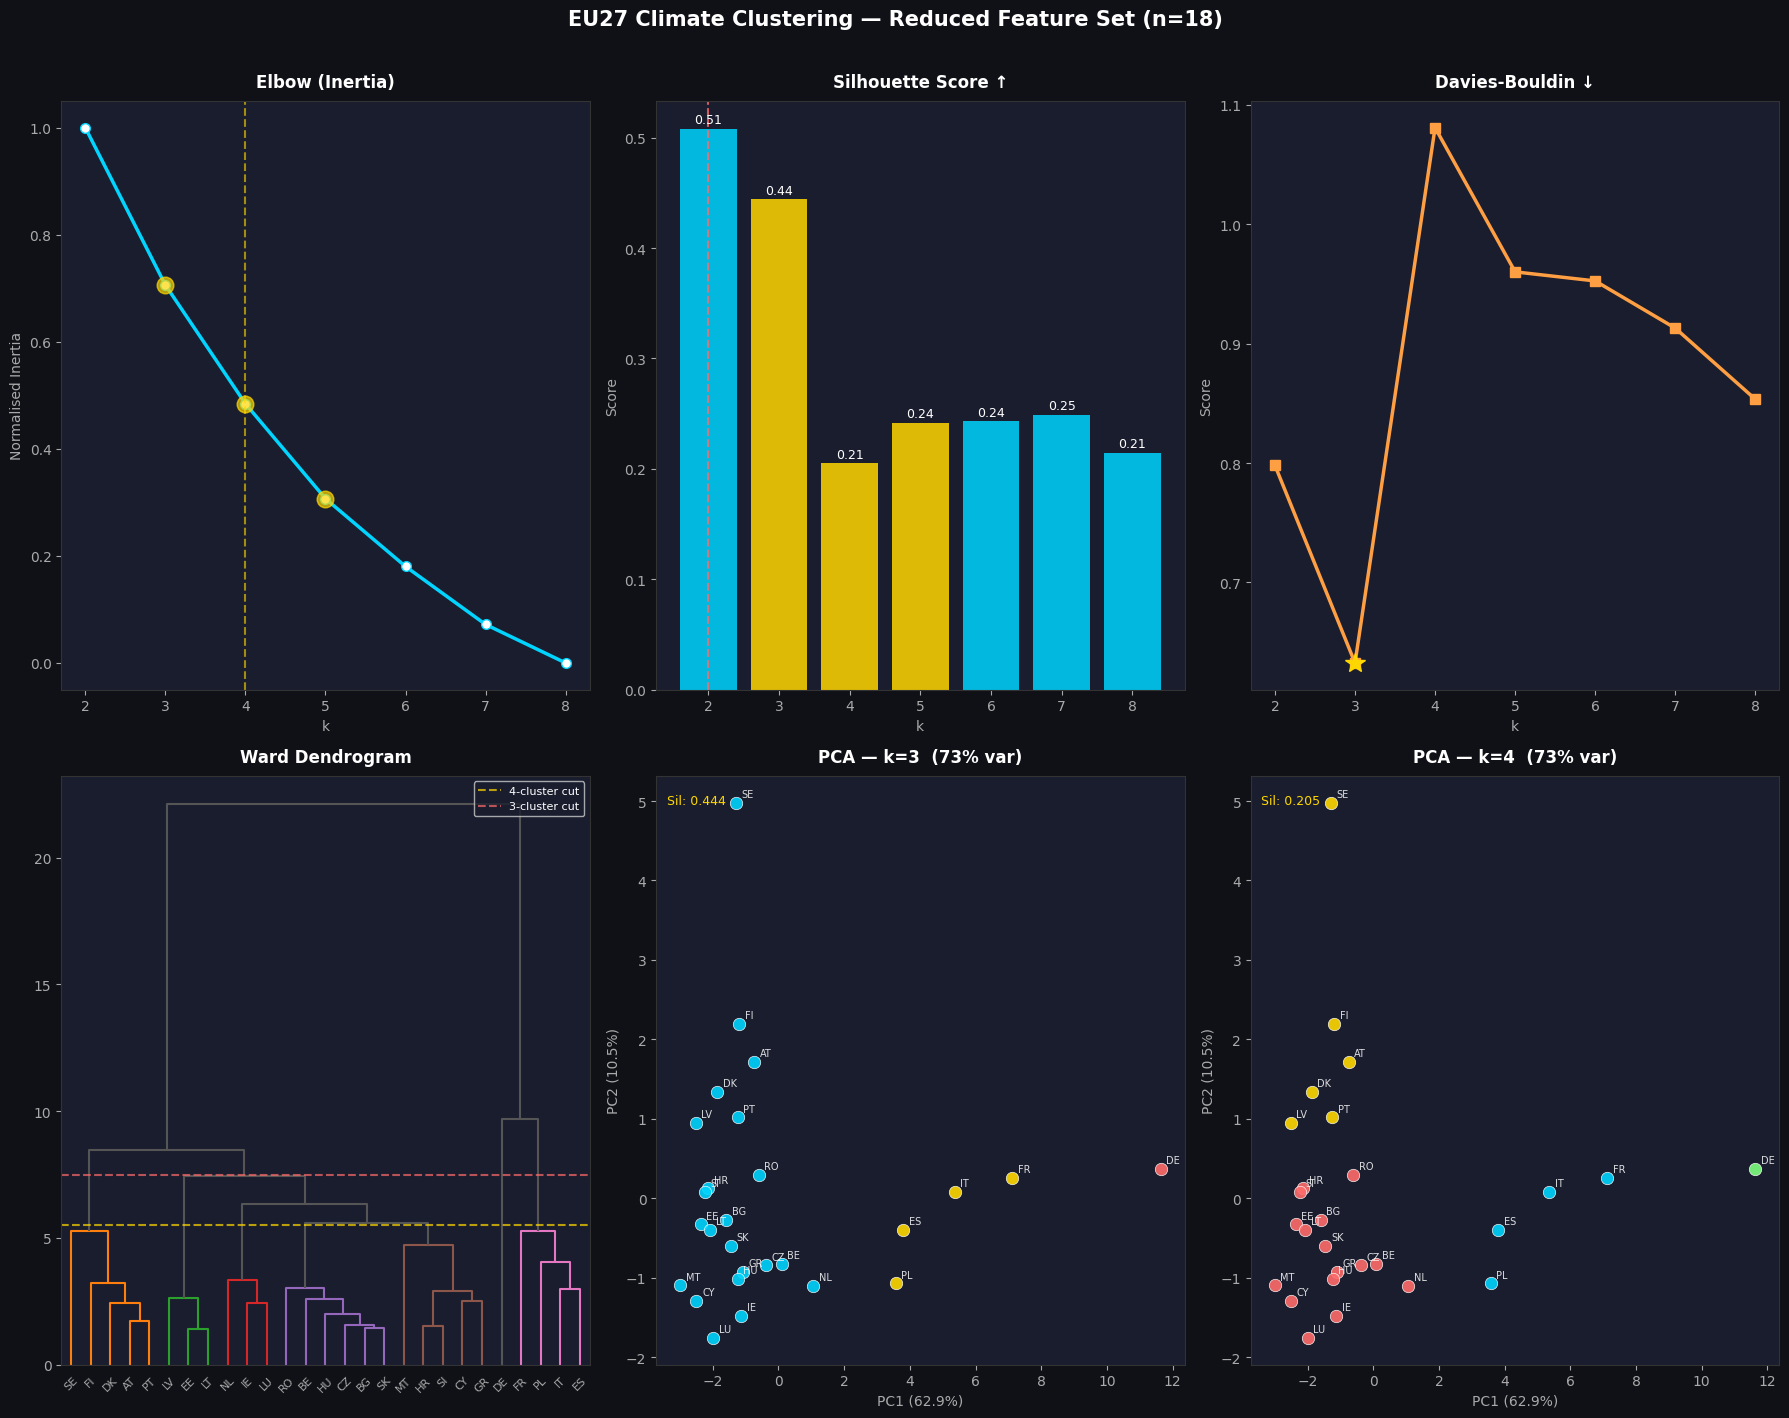

Figure saved → cluster_k_analysis_reduced.png


In [6]:
DARK_BG  = "#0f1117"
PANEL_BG = "#1a1d2e"
COLORS   = ["#00d4ff", "#ff6b6b", "#ffd700", "#7fff7f", "#ff9f43", "#a29bfe", "#fd79a8"]
k_list   = list(K_RANGE)

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(DARK_BG)

# — Elbow ——————————————————————————————————————————————
ax1 = fig.add_subplot(2, 3, 1)
ax1.set_facecolor(PANEL_BG)
inertia_norm = np.array(inertia)
inertia_norm = (inertia_norm - inertia_norm.min()) / (inertia_norm.max() - inertia_norm.min())
ax1.plot(k_list, inertia_norm, color="#00d4ff", linewidth=2.5,
         marker="o", markersize=7, markerfacecolor="white")
for k_val in [3, 4, 5]:
    ax1.plot(k_val, inertia_norm[k_val - 2], "o", markersize=12,
             color="#ffd700", zorder=5, alpha=0.7)
ax1.axvline(x=FINAL_K, color="#ffd700", linestyle="--", alpha=0.6, linewidth=1.5)
ax1.set_title("Elbow (Inertia)", color="white", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("k", color="#aaa"); ax1.set_ylabel("Normalised Inertia", color="#aaa")
ax1.tick_params(colors="#aaa"); ax1.spines[:].set_edgecolor("#333")

# — Silhouette ————————————————————————————————————————
ax2 = fig.add_subplot(2, 3, 2)
ax2.set_facecolor(PANEL_BG)
bar_colors = ["#ffd700" if k in [3, 4, 5] else "#00d4ff" for k in k_list]
ax2.bar(k_list, sil, color=bar_colors, alpha=0.85, edgecolor="none")
best_sil_k = k_list[sil.index(max(sil))]
ax2.axvline(x=best_sil_k, color="#ff6b6b", linestyle="--", linewidth=1.5, alpha=0.8)
for i, v in enumerate(sil):
    ax2.text(k_list[i], v + 0.005, f"{v:.2f}", ha="center", color="white", fontsize=9)
ax2.set_title("Silhouette Score ↑", color="white", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("k", color="#aaa"); ax2.set_ylabel("Score", color="#aaa")
ax2.tick_params(colors="#aaa"); ax2.spines[:].set_edgecolor("#333")

# — Davies-Bouldin ————————————————————————————————————
ax3 = fig.add_subplot(2, 3, 3)
ax3.set_facecolor(PANEL_BG)
ax3.plot(k_list, db, color="#ff9f43", linewidth=2.5, marker="s", markersize=7)
best_db_k = k_list[db.index(min(db))]
ax3.plot(best_db_k, db[best_db_k - 2], "*", markersize=15, color="#ffd700", zorder=5)
ax3.set_title("Davies-Bouldin ↓", color="white", fontsize=12, fontweight="bold", pad=10)
ax3.set_xlabel("k", color="#aaa"); ax3.set_ylabel("Score", color="#aaa")
ax3.tick_params(colors="#aaa"); ax3.spines[:].set_edgecolor("#333")

# — Dendrogram ————————————————————————————————————————
ax4 = fig.add_subplot(2, 3, 4)
ax4.set_facecolor(PANEL_BG)
dendrogram(Z, labels=codes, ax=ax4, color_threshold=5.5,
           above_threshold_color="#555", leaf_font_size=8)
ax4.axhline(y=5.5, color="#ffd700", linestyle="--", alpha=0.7,
            linewidth=1.5, label="4-cluster cut")
ax4.axhline(y=7.5, color="#ff6b6b", linestyle="--", alpha=0.7,
            linewidth=1.5, label="3-cluster cut")
ax4.legend(fontsize=8, facecolor=PANEL_BG, labelcolor="white")
ax4.set_title("Ward Dendrogram", color="white", fontsize=12, fontweight="bold", pad=10)
ax4.tick_params(colors="#aaa"); ax4.spines[:].set_edgecolor("#333")

# — PCA scatter k=3 and k=4 ———————————————————————————
for idx, k in enumerate([3, 4]):
    ax = fig.add_subplot(2, 3, 5 + idx)
    ax.set_facecolor(PANEL_BG)
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X)
    for cl in range(k):
        mask = labels == cl
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=COLORS[cl], s=80, alpha=0.9,
                   edgecolors="white", linewidth=0.5)
        for i, code in enumerate(codes):
            if mask[i]:
                ax.annotate(code, (X_pca[i, 0], X_pca[i, 1]),
                            fontsize=7, color="white", alpha=0.85,
                            xytext=(4, 4), textcoords="offset points")
    sil_k = silhouette_score(X, labels)
    ax.text(0.02, 0.97, f"Sil: {sil_k:.3f}", transform=ax.transAxes,
            color="#ffd700", fontsize=9, va="top")
    ax.set_title(f"PCA — k={k}  ({sum(var_exp):.0f}% var)",
                 color="white", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", color="#aaa")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", color="#aaa")
    ax.tick_params(colors="#aaa"); ax.spines[:].set_edgecolor("#333")

plt.suptitle(f"EU27 Climate Clustering — Reduced Feature Set (n={len(feature_cols)})",
             color="white", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_IMG, dpi=160, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print(f"Figure saved → {OUTPUT_IMG}")


## 6. Final Cluster Assignment

In [7]:
km_final     = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=20)
final_labels = km_final.fit_predict(X)

print(f"Final clustering  (k={FINAL_K})")
print("=" * 50)
for c in range(FINAL_K):
    members = [countries[i] for i in range(len(countries)) if final_labels[i] == c]
    print(f"\nCluster {c+1} ({len(members)} countries):")
    print("  " + ", ".join(members))


Final clustering  (k=4)

Cluster 1 (4 countries):
  France, Italy, Poland, Spain

Cluster 2 (16 countries):
  Belgium, Bulgaria, Croatia, Cyprus, Czechia, Estonia, Greece, Hungary, Ireland, Lithuania, Luxembourg, Malta, Netherlands, Romania, Slovakia, Slovenia

Cluster 3 (6 countries):
  Austria, Denmark, Finland, Latvia, Portugal, Sweden

Cluster 4 (1 countries):
  Germany


## 7. Cluster Feature Profiles

Mean standardised value per cluster for each of the 18 features.  
Green = above average, Red = below average — useful for naming/interpreting clusters.


In [8]:
df_profile = df[feature_cols].copy()
df_profile["Cluster"] = final_labels + 1

profile = df_profile.groupby("Cluster").mean().T
profile.columns = [f"Cluster {c}" for c in profile.columns]
profile.style.background_gradient(cmap="RdYlGn", axis=1).format(precision=2)


,Cluster 1,Cluster 2,Cluster 3,Cluster 4
FEC_Impl_Gap_Pct,0.60,-0.25,0.07,1.23
GHG_Impl_Gap_Pct,0.53,-0.12,0.02,-0.32
RES_Impl_Gap_Pct,-0.12,0.03,0.11,-0.60
FEC_Households,1.33,-0.43,-0.34,3.60
FEC_Industry,1.12,-0.44,-0.23,3.96
FEC_Services,1.34,-0.43,-0.33,3.58
FEC_Transport,1.64,-0.46,-0.38,3.10
GHG_Agriculture,1.70,-0.42,-0.43,2.46
GHG_Buildings,1.30,-0.38,-0.48,3.75
GHG_Fuel_Exploitation,1.44,-0.38,-0.50,3.35


## 8. Export Labels

In [9]:
df_out = df[["Country", "Country_Code"]].copy()
df_out[f"Cluster_k{FINAL_K}"] = final_labels + 1

df_out.to_csv("EU27_cluster_labels_reduced.csv", index=False)
print("Saved → EU27_cluster_labels_reduced.csv")
df_out


Saved → EU27_cluster_labels_reduced.csv


,Country,Country_Code,Cluster_k4
0,Austria,AT,3
1,Belgium,BE,2
2,Bulgaria,BG,2
3,Croatia,HR,2
4,Cyprus,CY,2
5,Czechia,CZ,2
6,Denmark,DK,3
7,Estonia,EE,2
8,Finland,FI,3
9,France,FR,1
